Create code to find plausability of finding a halo mass of that size at a certain redshift. This will be used to compare the plausability using current stellar masses and those derived using a varying IMF

In [227]:
from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt

f_baryon = 0.158 # usiing Watson model Omb/Omm

# grab data of JADES-GS-z14-0 from the fixed z_spec fit
path_to_data = '/home/caltech-msanche3/data/jades_eazy_output/fit_data/jades_run_60k_183348.zout.fits'
data = Table.read(path_to_data, format='fits')
obj = data[55102]
obj_stellar_mass = obj['mass']
obj_min_halo_mass = obj_stellar_mass/f_baryon
obj_z = obj['z_spec']

print('Reshift: z =',obj_z)
print('Mass =',obj_mass,'Solar Masses')


Reshift: z = 14.32
Mass = 131472230.72185187 Solar Masses


In [228]:
import matplotlib.pyplot as plt  # The necessary plotting library
import numpy as np  # Numerical array library
from hmf import MassFunction  # The main hmf class
from hmf.mass_function.fitting_functions import Watson # model specialized for high redshift
from hmf.mass_function.fitting_functions import SMT

# generate theoretical halo mass function at z=14.32

'''
# use this to generate all parameters and their meanings

MassFunction.get_all_parameter_defaults(recursive=False)
MassFunction.parameter_info(["hmf_model", "sigma_8"])
'''
MassFunction.get_all_parameter_defaults(recursive=False)
# load HMF model
mf = MassFunction(
    z=14.32,
    Mmin=5,
    Mmax=15,
    hmf_model=Watson,
)


/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/hmf/density_field/transfer.py:230: UserWarning: 'extrapolate_with_eh' was not set. Defaulting to True, which is different behaviour than versions <=3.4.4. This warning may be removed in v4.0. Silence it by setting extrapolate_with_eh explicitly.
  return self.transfer_model(self.cosmo, **self.transfer_params)


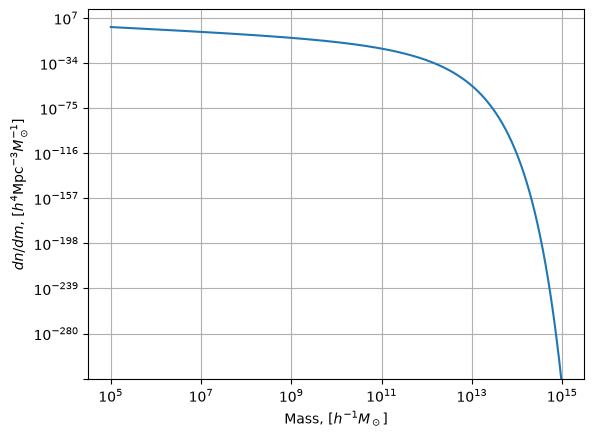

In [229]:
plt.plot(mf.m, mf.dndm)
plt.xscale("log")
plt.yscale("log")

plt.xlabel(r"Mass, $[h^{-1}M_\odot]$")
plt.ylabel(r"$dn/dm$, $[h^{4}{\rm Mpc}^{-3}M_\odot^{-1}]$")
plt.grid(axis='both')

In [230]:
from scipy.integrate import simpson

# define mass bounds
# lower bound represents mass of JADES-GS-z14-0
# upp bound attempts to capture the rest of the function
M1 = obj_min_halo_mass
M2 = 1e16 # really big to get all the function in the integral

# Create a boolean mask for your mass range
mask = (mf.m >= M1) & (mf.m <= M2)

# Integrate just that sliced segment
n_window = simpson(mf.dndm[mask], x=mf.m[mask])
print(f"Total number density: {n_window:.4e} h^3 Mpc^-3")

Total number density: 5.7735e-03 h^3 Mpc^-3


In [231]:
import numpy as np
from astropy.cosmology import Planck18
h = 0.6774

# calculate survey volume 
# define redshift bin
z_lo = 14.32 - 0.5
z_hi = 14.32 + 0.5

# 1. Define your survey sky coverage
# For example, JWST JADES Deep is roughly 45 arcmin^2
area_arcmin2 = 25.6 

# Convert sky area to steradians (sr)
# (1 arcmin^2 = 8.4616e-8 steradians)
area_steradians = area_arcmin2 * (np.pi / (180.0 * 60.0))**2

# Calculate comoving distance
r_min = Planck18.comoving_distance(z_lo).value * h # in Mpc/h
r_max = Planck18.comoving_distance(z_hi).value * h # in Mpc/h

# 4. Compute the comoving volume of your specific survey pencil-beam
survey_volume = (area_steradians / 3.0) * (r_max**3 - r_min**3) # units: (Mpc/h)^3

print(f"Survey Volume: {survey_volume:.4f} (Mpc/h)^3")

Survey Volume: 9567.1413 (Mpc/h)^3


In [232]:
# calculate the total count of objects in the volume

# 5. Multiply number density by volume
total_count = n_window * survey_volume

print(f"Expected number of halos in this bin: {total_count:.4f}")

Expected number of halos in this bin: 55.2362


In [233]:
# calculate probability of finding halo of this mass or greater

# calculate total
n_total = simpson(mf.dndm, x=mf.m)

# 3. The relative probability
prob = n_window / n_total

print(f"Probability that a detected halo falls in this mass range: {prob:.6%}")

Probability that a detected halo falls in this mass range: 0.000100%
